# **M2-1: PCA Variants + Manifold Learning Demo**

### ZG513 Advanced Deep Learning | BITS Pilani WILP

### Author: Seetha Parameswaran

---

**Purpose**
Demonstrate that no single dimensionality reduction method dominates across all data regimes. Students observe how each variant addresses a specific limitation of standard PCA — scale, nonlinearity, streaming, sparsity — and how manifold methods reveal cluster structure invisible to linear projections.

---

**Learning Objectives**
- Visually confirm that Standard, Randomized, and Incremental PCA produce near-identical 2D embeddings — reinforcing that algorithmic differences are about *computational efficiency*, not representational power
- Observe Kernel PCA (RBF) separating digit classes that overlap under linear PCA — connecting the kernel trick to nonlinear structure
- Read a scree plot and identify the elbow; determine components needed for 90% variance
- Interpret Sparse PCA loading heatmap — identify which pixel regions (features) are active vs zeroed out per component
- Compare LLE, Isomap, t-SNE, UMAP embeddings of the same data — understand local vs global structure preservation trade-offs

---

**Input Dataset**
`sklearn.datasets.load_digits`
- 1797 handwritten digit images, classes 0--9
- Each sample: 8×8 pixel image flattened to 64 features
- Standardized to zero mean, unit variance before all methods
- Manifold learning uses a 500-sample random subset (computational constraint for $\mathcal{O}(n^2)$ methods)

---

Libraries needed
- pip install scikit-learn matplotlib scipy
- pip install umap-learn   # optional, UMAP panel skipped gracefully if absent

---
M2-outputs/
  - M2-1-PCA_Scree.png
  - M2-1-PCA_Scatter.png
  - M2-1-Manifold.png


In [1]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import (PCA, IncrementalPCA, KernelPCA,
                                   SparsePCA, FactorAnalysis)
from sklearn.manifold import LocallyLinearEmbedding, Isomap, TSNE
from scipy.stats import spearmanr
from sklearn.metrics import pairwise_distances

warnings.filterwarnings('ignore')

# ── output folder ────────────────────────────────────────────
OUT = 'M2-outputs'
os.makedirs(OUT, exist_ok=True)

# ── umap (optional) ─────────────────────────────────────────
try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("WARNING: umap-learn not installed -- UMAP panel skipped. "
          "pip install umap-learn")

CMAP   = plt.cm.tab10
COLORS = [CMAP(i) for i in range(10)]

2026-04-27 16:44:04.358219: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-04-27 16:44:04.358244: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
# ============================================================
# DATA
# ============================================================
digits      = load_digits()
X, y        = digits.data, digits.target          # (1797, 64)
scaler      = StandardScaler()
X_sc        = scaler.fit_transform(X)

N_MANIFOLD  = 500
rng         = np.random.default_rng(42)
idx         = rng.choice(len(X_sc), N_MANIFOLD, replace=False)
X_sub, y_sub = X_sc[idx], y[idx]

In [3]:
# ============================================================
# HELPERS
# ============================================================
def scatter2d(ax, Z, labels, title, legend=False):
    for c in range(10):
        m = labels == c
        ax.scatter(Z[m, 0], Z[m, 1], s=8, color=COLORS[c],
                   alpha=0.7, label=str(c))
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    if legend:
        ax.legend(markerscale=2, fontsize=6, ncol=2,
                  loc='lower right', framealpha=0.5)

def var_bar(ax, ratios, title, k=20):
    cum = np.cumsum(ratios[:k])
    ax.bar(range(1, k+1), ratios[:k], color='steelblue', alpha=0.7, label='Individual')
    ax.plot(range(1, k+1), cum, 'r-o', ms=3, label='Cumulative')
    ax.axhline(0.9, color='gray', ls='--', lw=0.8, label='90%')
    ax.set_xlabel('Component', fontsize=7)
    ax.set_ylabel('Explained Variance Ratio', fontsize=7)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=6)

In [4]:
# ============================================================
# SECTION 1: PCA VARIANTS
# ============================================================
print("=" * 55)
print("PCA Variants")
print("=" * 55)

# Standard PCA
pca    = PCA(n_components=40, random_state=42)
Z_pca  = pca.fit_transform(X_sc)
n90    = np.searchsorted(np.cumsum(pca.explained_variance_ratio_), 0.90) + 1
print(f"[Standard PCA]    components for 90% variance: {n90}")

# Randomized PCA
rpca   = PCA(n_components=20, svd_solver='randomized', random_state=42)
Z_rpca = rpca.fit_transform(X_sc)
print(f"[Randomized PCA]  top-20 cumul. var: "
      f"{np.sum(rpca.explained_variance_ratio_):.3f}")

# Incremental PCA
ipca      = IncrementalPCA(n_components=20, batch_size=200)
Z_ipca    = ipca.fit_transform(X_sc)
n_batches = int(np.ceil(len(X_sc) / 200))
print(f"[Incremental PCA] batches: {n_batches}  "
      f"top-20 cumul. var: {np.sum(ipca.explained_variance_ratio_):.3f}")

# Kernel PCA
kpca   = KernelPCA(n_components=2, kernel='rbf', gamma=0.01, random_state=42)
Z_kpca = kpca.fit_transform(X_sc)
print(f"[Kernel PCA]      embedding shape: {Z_kpca.shape}")

# Probabilistic PCA
ppca   = FactorAnalysis(n_components=20, random_state=42)
Z_ppca = ppca.fit_transform(X_sc)
print(f"[Probabilistic PCA] log-likelihood/sample: {ppca.score(X_sc):.3f}")

# Sparse PCA (subset -- slow)
spca   = SparsePCA(n_components=5, alpha=1.0, random_state=42, max_iter=200)
Z_spca = spca.fit_transform(X_sc[:300])
n_zero = np.sum(spca.components_ == 0)
total  = spca.components_.size
print(f"[Sparse PCA]      zero loadings: {n_zero}/{total} "
      f"({100*n_zero/total:.1f}%)")

print("\n-- Explained Variance (top-20) --")
print(f"{'Method':<20} {'CumulVar':>10}")
print("-" * 32)
for nm, ev in [('Standard PCA',    np.sum(pca.explained_variance_ratio_[:20])),
               ('Randomized PCA',  np.sum(rpca.explained_variance_ratio_)),
               ('Incremental PCA', np.sum(ipca.explained_variance_ratio_))]:
    print(f"{nm:<20} {ev:>10.4f}")
print(f"{'PPCA':<20} {'(see LL)':>10}")

PCA Variants
[Standard PCA]    components for 90% variance: 31
[Randomized PCA]  top-20 cumul. var: 0.793
[Incremental PCA] batches: 9  top-20 cumul. var: 0.781
[Kernel PCA]      embedding shape: (1797, 2)
[Probabilistic PCA] log-likelihood/sample: -28.586
[Sparse PCA]      zero loadings: 162/320 (50.6%)

-- Explained Variance (top-20) --
Method                 CumulVar
--------------------------------
Standard PCA             0.7931
Randomized PCA           0.7930
Incremental PCA          0.7811
PPCA                   (see LL)



[Saved] M2-outputs/M2-1-PCA_Scree.png


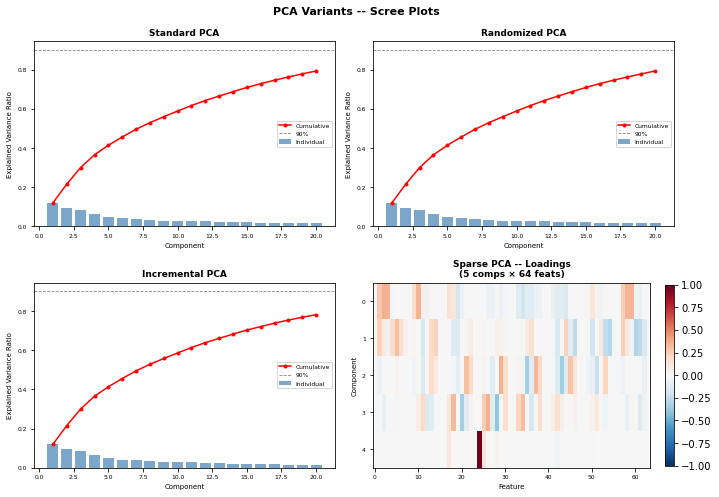

[Saved] M2-outputs/M2-1-PCA_Scatter.png


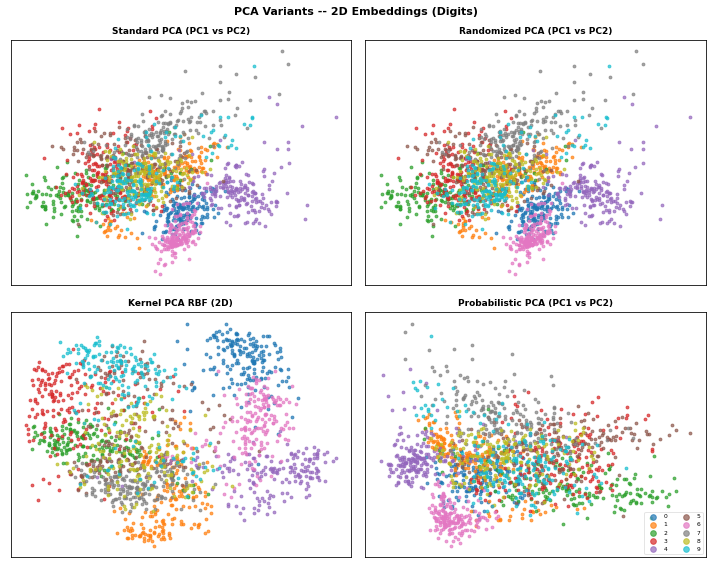

In [5]:
# ============================================================
# FIGURE 1a: Scree plots (2x2)
# ============================================================
fig1a, axes1a = plt.subplots(2, 2, figsize=(10, 7))
fig1a.suptitle('PCA Variants -- Scree Plots', fontsize=11, fontweight='bold')

var_bar(axes1a[0, 0], pca.explained_variance_ratio_,  'Standard PCA')
var_bar(axes1a[0, 1], rpca.explained_variance_ratio_, 'Randomized PCA')
var_bar(axes1a[1, 0], ipca.explained_variance_ratio_, 'Incremental PCA')

# Sparse PCA: loading sparsity heatmap in 4th panel
im = axes1a[1, 1].imshow(spca.components_, aspect='auto',
                          cmap='RdBu_r', vmin=-1, vmax=1)
axes1a[1, 1].set_title('Sparse PCA -- Loadings\n(5 comps × 64 feats)',
                        fontsize=9, fontweight='bold')
axes1a[1, 1].set_xlabel('Feature', fontsize=7)
axes1a[1, 1].set_ylabel('Component', fontsize=7)
axes1a[1, 1].tick_params(labelsize=6)
plt.colorbar(im, ax=axes1a[1, 1], fraction=0.03)

plt.tight_layout()
path1a = os.path.join(OUT, 'M2-1-PCA_Scree.png')
plt.savefig(path1a, dpi=150, bbox_inches='tight')
print(f"\n[Saved] {path1a}")
plt.show()

# ============================================================
# FIGURE 1b: 2D Scatter plots (2x2)
# ============================================================
fig1b, axes1b = plt.subplots(2, 2, figsize=(10, 8))
fig1b.suptitle('PCA Variants -- 2D Embeddings (Digits)', fontsize=11, fontweight='bold')

scatter2d(axes1b[0, 0], Z_pca[:, :2],  y, 'Standard PCA (PC1 vs PC2)')
scatter2d(axes1b[0, 1], Z_rpca[:, :2], y, 'Randomized PCA (PC1 vs PC2)')
scatter2d(axes1b[1, 0], Z_kpca,        y, 'Kernel PCA RBF (2D)')
scatter2d(axes1b[1, 1], Z_ppca[:, :2], y, 'Probabilistic PCA (PC1 vs PC2)', legend=True)

plt.tight_layout()
path1b = os.path.join(OUT, 'M2-1-PCA_Scatter.png')
plt.savefig(path1b, dpi=150, bbox_inches='tight')
print(f"[Saved] {path1b}")
plt.show()

In [6]:
# ============================================================
# SECTION 2: MANIFOLD LEARNING
# ============================================================
print("\n" + "=" * 55)
print("Manifold Learning")
print("=" * 55)

def safe_embed(name, estimator, X):
    """Fit estimator, catch AttributeError gracefully (e.g. NoneType.split)."""
    try:
        Z = estimator.fit_transform(X)
        return Z
    except AttributeError as e:
        print(f"  WARNING [{name}]: {e} -- skipping")
        return None

# LLE
lle   = LocallyLinearEmbedding(n_components=2, n_neighbors=15,
                                method='standard', random_state=42)
Z_lle = safe_embed('LLE', lle, X_sub)
if Z_lle is not None:
    print(f"[LLE]    reconstruction error: {lle.reconstruction_error_:.6f}")

# Isomap
iso   = Isomap(n_components=2, n_neighbors=10)
Z_iso = safe_embed('Isomap', iso, X_sub)
if Z_iso is not None:
    print(f"[Isomap] embedding shape: {Z_iso.shape}")

# t-SNE
tsne   = TSNE(n_components=2, perplexity=30, n_iter=1000,
              random_state=42, init='pca')
Z_tsne = safe_embed('t-SNE', tsne, X_sub)
if Z_tsne is not None:
    print(f"[t-SNE]  KL divergence: {tsne.kl_divergence_:.4f}")

# UMAP
Z_umap = None
if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, n_neighbors=15,
                        min_dist=0.1, random_state=42)
    Z_umap = safe_embed('UMAP', reducer, X_sub)
    if Z_umap is not None:
        print(f"[UMAP]   embedding shape: {Z_umap.shape}")

# Spearman distance correlation
print("\n-- Spearman rho: embedded vs original distances --")
D_orig = pairwise_distances(X_sub)
triu   = np.triu_indices(N_MANIFOLD, k=1)
d_orig = D_orig[triu]
for nm, Z in [('LLE', Z_lle), ('Isomap', Z_iso),
              ('t-SNE', Z_tsne), ('UMAP', Z_umap)]:
    if Z is None:
        print(f"  {nm:<8} skipped")
        continue
    try:
        r, _ = spearmanr(d_orig, pairwise_distances(Z)[triu])
        print(f"  {nm:<8} rho = {r:.4f}")
    except Exception as e:
        print(f"  {nm:<8} WARNING: {e}")


Manifold Learning


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fd66ace9820>
Traceback (most recent call last):
  File "/home/seetha/PythonScriptsCourses/PythonScriptsCourses/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/seetha/PythonScriptsCourses/PythonScriptsCourses/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/seetha/PythonScriptsCourses/PythonScriptsCourses/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/seetha/PythonScriptsCourses/PythonScriptsCourses/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


[LLE]    reconstruction error: 0.000020


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7fd66ace9820>
Traceback (most recent call last):
  File "/home/seetha/PythonScriptsCourses/PythonScriptsCourses/lib/python3.8/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/seetha/PythonScriptsCourses/PythonScriptsCourses/lib/python3.8/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/seetha/PythonScriptsCourses/PythonScriptsCourses/lib/python3.8/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/seetha/PythonScriptsCourses/PythonScriptsCourses/lib/python3.8/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


[Isomap] embedding shape: (500, 2)
[t-SNE]  KL divergence: 0.6143
[UMAP]   embedding shape: (500, 2)

-- Spearman rho: embedded vs original distances --
  LLE      rho = 0.3221
  Isomap   rho = 0.5642
  t-SNE    rho = 0.4192
  UMAP     rho = 0.2878



[Saved] M2-outputs/M2-1-Manifold.png


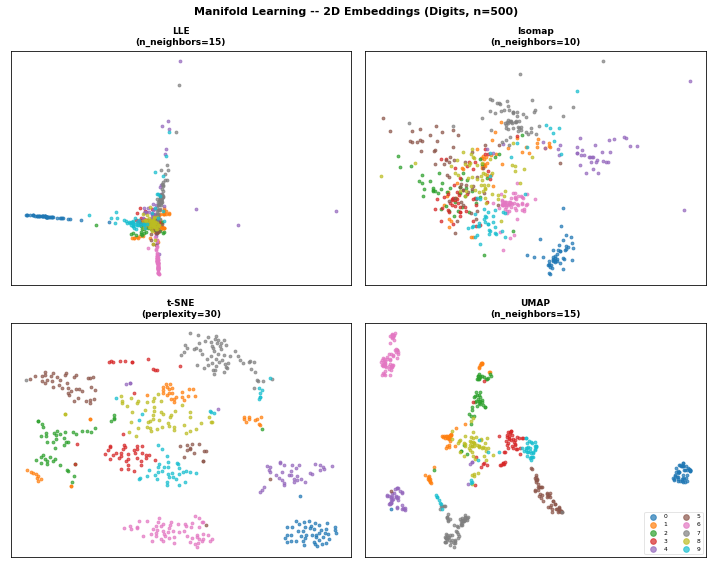

In [7]:
# ============================================================
# FIGURE 2: Manifold Learning (2x2)
# ============================================================
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))
fig2.suptitle('Manifold Learning -- 2D Embeddings (Digits, n=500)',
              fontsize=11, fontweight='bold')

panels = [
    ('LLE\n(n_neighbors=15)',   Z_lle,   axes2[0, 0]),
    ('Isomap\n(n_neighbors=10)',Z_iso,   axes2[0, 1]),
    ('t-SNE\n(perplexity=30)',  Z_tsne,  axes2[1, 0]),
    ('UMAP\n(n_neighbors=15)',  Z_umap,  axes2[1, 1]),
]

for title, Z, ax in panels:
    if Z is not None:
        scatter2d(ax, Z, y_sub, title, legend=title.startswith('UMAP'))
    else:
        ax.text(0.5, 0.5, f'{title}\nnot available',
                ha='center', va='center', transform=ax.transAxes, fontsize=9)
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
path2 = os.path.join(OUT, 'M2-1-Manifold.png')
plt.savefig(path2, dpi=150, bbox_inches='tight')
print(f"\n[Saved] {path2}")
plt.show()



**How to Read the Results**

*Scree plots (Fig 1a):*
- Blue bars = individual explained variance ratio per component
- Red line = cumulative explained variance
- Gray dashed = 90% threshold
- Standard / Randomized / Incremental should show nearly identical curves — confirms approximation quality of Randomized and correctness of Incremental
- Elbow typically around component 10--15 for digits

*Sparse PCA heatmap (Fig 1a, panel 4):*
- Rows = 5 components; columns = 64 pixel features
- White/near-zero entries = features suppressed by $\ell_1$ penalty
- Non-zero entries (red/blue) = active pixels; interpret as localized stroke detectors

*2D scatter plots (Fig 1b):*
- Each point = one digit image; color = true class label (0--9)
- Standard / Randomized / Probabilistic PCA: expect partial separation — digits 0, 1, 4 tend to separate; 3/5/8 overlap
- Kernel PCA RBF: tighter clusters due to nonlinear mapping — compare directly with Standard PCA panel
- Perfect separation is not expected in 2D — 64D structure cannot be fully captured in 2 components

*Manifold learning 2×2 (Fig 2):*
- LLE: preserves local reconstruction; good local clusters but may distort global layout
- Isomap: geodesic distances — better global structure than LLE; digit clusters more evenly spaced
- t-SNE: tightest, most visually separated clusters — optimized for local neighborhood; inter-cluster distances are *not* meaningful
- UMAP: combines local and global; fastest; clusters comparable to t-SNE but with more preserved global geometry
- Spearman $\rho$ printed to console: measures rank correlation between original and embedded pairwise distances — Isomap typically highest ($\rho \approx 0.56$) confirming best global structure preservation; t-SNE and UMAP lower $\rho$ reflecting their local focus

---

**Conclusion**
- For *compression and reconstruction*: Standard or Randomized PCA; use Incremental when data does not fit in RAM
- For *nonlinear separation*: Kernel PCA; choice of kernel and $\gamma$ critical
- For *interpretability*: Sparse PCA; active features reveal semantically meaningful pixel regions
- For *visualization*: t-SNE for publication-quality cluster plots; UMAP for large-scale or when global structure matters
- Spearman $\rho$ provides a quantitative complement to visual inspection — neither metric alone is sufficient